# Circuit Execution Quality Metrics

This tutorial covers benchmarks for measuring full circuit performance.

In [2]:
from qcmet import QuantumVolumeFixedQubits
from qcmet.devices import IdealSimulator, NoisySimulator
import matplotlib.pyplot as plt

The circuit execution quality metrics consist of:

- Quantum volume (QuantumVolumeFixedQubits)

- Mirrored circuits average polarization (MirroredCircuits)

- Upper bound on the variation distance (UpperBoundOnVD)


## Quantum Volume

Quantum Volume (QV) is a holistic benchmark that measures the largest random circuit a quantum computer can execute successfully.

### How Quantum Volume Works

1. Generate random unitary circuits of depth = width = n
2. Execute circuits and collect measurement statistics
3. Compute Heavy Output Probability (HOP)
4. If HOP > 2/3 with high confidence, QV = 2^n

QV captures:
- Gate fidelity
- Measurement fidelity
- Circuit connectivity
- Crosstalk
- Compilation quality

In [3]:
# Setup Quantum Volume benchmark
qv = QuantumVolumeFixedQubits(
    qubits=3,      # Test 3-qubit QV
    trials=20,     # Number of random circuits
    seed=42,       # For reproducibility
)

# Generate circuits
qv.generate_circuits()
print(f"Generated {len(qv.circuits)} QV circuits")
print(f"Each circuit has width={qv.num_qubits} and depth={qv.num_qubits}")

Generated 20 QV circuits
Each circuit has width=3 and depth=3


In [4]:
# Look at a QV circuit
print("Example Quantum Volume circuit:")
print(qv.circuits[-1])

Example Quantum Volume circuit:
           ┌──────┐      ┌──────┐   ┌──────┐ ░ ┌─┐      
   q_0: ─X─┤0     ├─X────┤0     ├───┤0     ├─░─┤M├──────
         │ │  su4 │ │    │  su4 │   │  su4 │ ░ └╥┘┌─┐   
   q_1: ─X─┤1     ├─X──X─┤1     ├─X─┤1     ├─░──╫─┤M├───
           └──────┘    │ └──────┘ │ └──────┘ ░  ║ └╥┘┌─┐
   q_2: ───────────────X──────────X──────────░──╫──╫─┤M├
                                             ░  ║  ║ └╥┘
meas: 3/════════════════════════════════════════╩══╩══╩═
                                                0  1  2 


In [5]:
# Run on ideal simulator
device = IdealSimulator()
qv.run(device, num_shots=1024)

# Analyze
results = qv.analyze()
print("\nQuantum Volume Results:")
for key, value in results.items():
    print(f"  {key}: {value}")


Quantum Volume Results:
  mean: 0.844384765625
  mean-2sigma: 0.6822742272843888
  outcome: Pass
  quantum_volume: >= 8


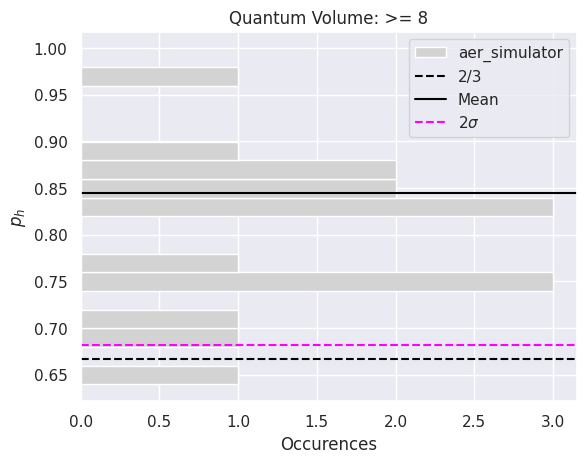

In [6]:
# Plot
qv.plot()
plt.show()

### Testing Different Qubit Counts

In [ ]:
# Test QV for different system sizes
device = NoisySimulator(overrotation_amount = 0, detuning_amount = 0, error_1q = 0.00, error_2q = 0.01, t1 = 0, t2 = 0 )
qv_results = {}

for n_qubits in [3, 4]:
    print(f"\nTesting QV for {n_qubits} qubits...")

    qv_test = QuantumVolumeFixedQubits(
        qubits=n_qubits,
        trials=50,
        seed=42,
    )

    qv_test.generate_circuits()
    qv_test.run(device, num_shots=1024)
    result = qv_test.analyze()
    qv_results[n_qubits] = result
    print(f"  QV = {result.get('quantum_volume', 'N/A')}")
    print(f"  mean HOP = {result.get('mean', 'N/A'):.3f}")
    print(f"  mean HOP - 2sigma = {result.get('mean-2sigma', 'N/A'):.3f}")
    print(f"  Passed: {result.get('outcome', 'N/A')}")


Testing QV for 3 qubits...
  QV = >= 8
  mean HOP = 0.809
  mean HOP - 2sigma = 0.698
  Passed: Pass

Testing QV for 4 qubits...
  QV = < 16
  mean HOP = 0.743
  mean HOP - 2sigma = 0.620
  Passed: Fail


### Interpreting the Results

**What QV Tells You:**
- QV = $2^{n}$ means the system can handle n-qubit circuits of depth n
- Higher QV = better overall quantum computer
- QV = 64 means 6 qubits × depth 6

**Heavy Output Probability (HOP):**
- Must exceed 2/3 (66.7%) to pass with a confidence of 2 sigma
- Measures fraction of "heavy" outputs (above median probability)
- HOP > 2/3 means circuits are executed correctly


## Other Benchmarks

QCMet furthermore implements mirrored circuits average polarization and the upper bound on the variation distance as circuit execution quality metrics.